In [1]:
import os, re
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import chi2 as chi2_dist

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATE        = "20250702"          # YYYYMMDD
SVD_DIR     = "/home/zhe2/data/PACE/svd_retrieval_output"
L2AOP_DIR   = "/home/zhe2/data/PACE/L2_AOP_V3.1"

# Clip chi2 for display (outliers from non-converged pixels are huge)
CHI2_XLIM   = (0, 10)
CHI2_NBINS  = 200

# ── FILE DISCOVERY ────────────────────────────────────────────────────────────
SVD_RE   = re.compile(r"^interim_(\d{8}T\d{6})_svd_retrieval_.*\.nc$")
L2AOP_RE = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L2\.OC_AOP.*\.nc$")

svd_files = sorted(
    os.path.join(SVD_DIR, f)
    for f in os.listdir(SVD_DIR)
    if SVD_RE.match(f) and f.startswith(f"interim_{DATE}")
)

l2aop_idx = {}
for fn in os.listdir(L2AOP_DIR):
    m = L2AOP_RE.match(fn)
    if m:
        l2aop_idx[m.group(1)] = os.path.join(L2AOP_DIR, fn)

def match_l2(gid):
    if gid in l2aop_idx: return l2aop_idx[gid]
    for k, v in l2aop_idx.items():
        if k[:-2] == gid[:-2]: return v
    return None

print(f"Found {len(svd_files)} SVD files for {DATE}")


Found 147 SVD files for 20250702


In [2]:
# ── LOAD ALL GRANULES ─────────────────────────────────────────────────────────
chi2_all   = []   # all pixels
stat_all   = []   # status code per pixel
flag_all   = []   # l2_flags (0 = clean) per pixel
nflh_all   = []   # nFLH valid boolean per pixel

for svd_path in svd_files:
    m   = SVD_RE.match(os.path.basename(svd_path))
    gid = m.group(1)
    l2_path = match_l2(gid)

    with nc.Dataset(svd_path, "r") as ds:
        chi2 = np.array(ds["reduced_chi2"][:]).ravel()
        stat = np.array(ds["status_code"][:]).ravel()

    chi2_all.append(chi2)
    stat_all.append(stat)

    if l2_path:
        with nc.Dataset(l2_path, "r") as ds:
            flags = np.array(ds["geophysical_data/l2_flags"][:]).ravel()
            nflh_var = ds["geophysical_data/nflh"]
            fv = float(nflh_var._FillValue) if hasattr(nflh_var, "_FillValue") else None
            nflh = np.ma.filled(nflh_var[:], np.nan).ravel()
        nflh_ok = np.isfinite(nflh) & (nflh != fv if fv is not None else True)
        flag_all.append(flags)
        nflh_all.append(nflh_ok)
    else:
        flag_all.append(np.full(len(chi2), -1, dtype=np.int32))
        nflh_all.append(np.zeros(len(chi2), dtype=bool))

chi2  = np.concatenate(chi2_all)
stat  = np.concatenate(stat_all)
flags = np.concatenate(flag_all)
nflh_ok = np.concatenate(nflh_all)

print(f"Total pixels: {len(chi2):,}")
print(f"  status=0: {np.sum(stat==0):,}   status=1: {np.sum(stat==1):,}   status>=2: {np.sum(stat>=2):,}")
print(f"  flag=0  : {np.sum(flags==0):,}")
print(f"  nFLH ok : {np.sum(nflh_ok):,}")


Total pixels: 314,639,376
  status=0: 30,803,041   status=1: 169,371,968   status>=2: 114,464,367
  flag=0  : 10,954,476
  nFLH ok : 49,141,188


#### <b>Chi2 distribution</b>

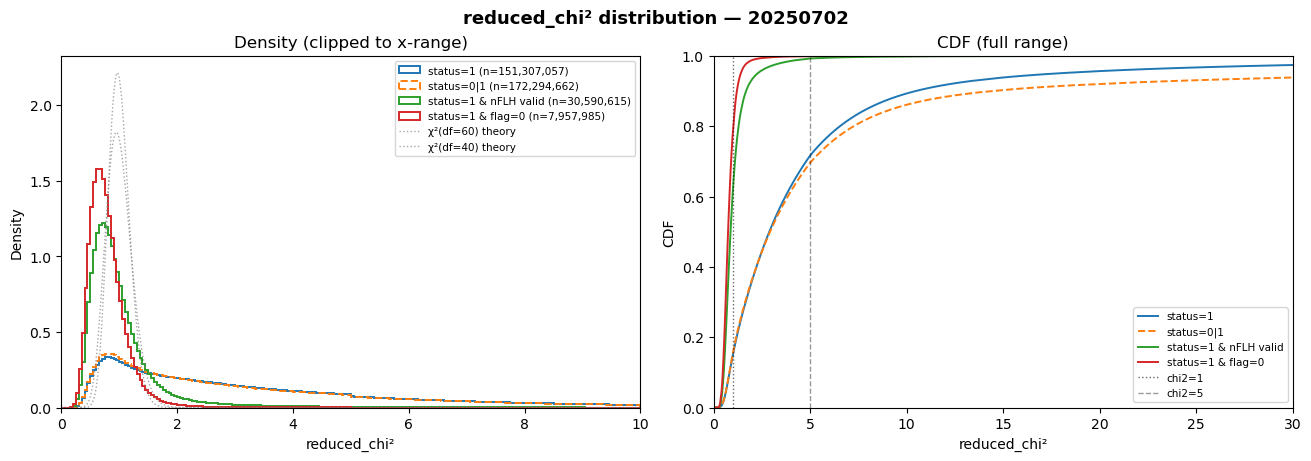

In [3]:
# ── PLOT: reduced_chi2 distribution by quality population ────────────────────
bins = np.linspace(*CHI2_XLIM, CHI2_NBINS + 1)

# Populations (mask, label, color, linestyle)
populations = [
    ((stat == 1),                              "status=1",             "C0",  "-"),
    ((stat == 0) | (stat == 1),                "status=0|1",           "C1",  "--"),
    ((stat == 1) & nflh_ok,                    "status=1 & nFLH valid","C2",  "-"),
    ((stat == 1) & (flags == 0),               "status=1 & flag=0",    "C3",  "-"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
fig.suptitle(f"reduced_chi² distribution — {DATE}", fontsize=13, fontweight="bold")

# --- left: density histogram ---
ax = axes[0]
for mask, label, color, ls in populations:
    vals = chi2[mask & np.isfinite(chi2)]
    vals = vals[(vals >= CHI2_XLIM[0]) & (vals <= CHI2_XLIM[1])]
    ax.hist(vals, bins=bins, density=True, histtype="step",
            color=color, linestyle=ls, linewidth=1.4, label=f"{label} (n={len(vals):,})")

# Theoretical chi2 PDF (df = n_meas - n_state; rough estimate df~60)
for df, ls in [(60, ":"), (40, ":")]:
    x = np.linspace(0.01, CHI2_XLIM[1], 500)
    y = chi2_dist.pdf(x * df, df=df) * df   # transform back to reduced chi2
    ax.plot(x, y, color="gray", linestyle=ls, linewidth=1, alpha=0.7,
            label=f"χ²(df={df}) theory")

ax.set_xlabel("reduced_chi²")
ax.set_ylabel("Density")
ax.set_xlim(CHI2_XLIM)
ax.legend(fontsize=7.5, loc="upper right")
ax.set_title("Density (clipped to x-range)")

# --- right: CDF ---
ax = axes[1]
for mask, label, color, ls in populations:
    vals = np.sort(chi2[mask & np.isfinite(chi2)])
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=color, linestyle=ls, linewidth=1.4, label=label)

ax.axvline(1.0, color="k", linestyle=":", linewidth=1, alpha=0.6, label="chi2=1")
ax.axvline(5.0, color="k", linestyle="--", linewidth=1, alpha=0.4, label="chi2=5")
ax.set_xlabel("reduced_chi²")
ax.set_ylabel("CDF")
ax.set_xlim(0, 30)
ax.set_ylim(0, 1)
ax.legend(fontsize=7.5, loc="lower right")
ax.set_title("CDF (full range)")

plt.show()


In [4]:
# ── THEORETICAL 95% range of reduced chi2 for various degrees of freedom ──────
# For a properly-calibrated retrieval, observed chi2 should fall in these bands.
print("Theoretical 95% interval of reduced chi² = chi2(df)/df")
print(f"  {'df':>5}  {'5th pct':>9}  {'95th pct':>10}  {'mean (=1)':>10}")
print("  " + "-" * 42)
for df in [20, 30, 40, 50, 60, 80, 100]:
    lo, hi = chi2_dist.ppf([0.05, 0.95], df=df) / df
    print(f"  {df:>5}  {lo:>9.4f}  {hi:>10.4f}  {1.0:>10.4f}")


Theoretical 95% interval of reduced chi² = chi2(df)/df
     df    5th pct    95th pct   mean (=1)
  ------------------------------------------
     20     0.5425      1.5705      1.0000
     30     0.6164      1.4591      1.0000
     40     0.6627      1.3940      1.0000
     50     0.6953      1.3501      1.0000
     60     0.7198      1.3180      1.0000
     80     0.7549      1.2735      1.0000
    100     0.7793      1.2434      1.0000


In [5]:
# ── SUMMARY STATISTICS TABLE ──────────────────────────────────────────────────
pcts = [50, 75, 90, 95, 99]

# Theoretical 5–95% range of reduced chi2 for df=60
DF_THEORY   = 60
CHI2_LO, CHI2_HI = chi2_dist.ppf([0.05, 0.95], df=DF_THEORY) / DF_THEORY
print(f"Theoretical chi²(df={DF_THEORY}) 5–95% range: [{CHI2_LO:.4f}, {CHI2_HI:.4f}]")
print()

populations_stat = [
    ((stat == 1),                   "status=1"),
    ((stat == 0) | (stat == 1),     "status=0|1"),
    ((stat == 1) & nflh_ok,         "status=1 & nFLH valid"),
    ((stat == 1) & (flags == 0),    "status=1 & flag=0"),
]

header = f"{'Population':<34} {'N':>10}  {'mean':>6}  {'median':>7}  " + \
         "  ".join(f"p{p:02d}" for p in pcts) + \
         f"  {'<1 (%)':>7}  {'<2 (%)':>7}  {'<5 (%)':>7}"
sep = "-" * len(header)
print(header)

def _print_row(label, vals):
    if len(vals) == 0:
        print(f"{label:<34}  (no data)")
        return
    ps     = np.percentile(vals, pcts)
    ps_str = "  ".join(f"{p:6.2f}" for p in ps)
    print(f"{label:<34} {len(vals):>10,}  {vals.mean():>6.2f}  {np.median(vals):>7.3f}  "
          f"{ps_str}  {100*np.mean(vals<1):>7.1f}  {100*np.mean(vals<2):>7.1f}  "
          f"{100*np.mean(vals<5):>7.1f}")

for mask, label in populations_stat:
    finite = mask & np.isfinite(chi2)
    vals_all      = chi2[finite]
    in_band       = (chi2 >= CHI2_LO) & (chi2 <= CHI2_HI)
    vals_filtered = chi2[finite & in_band]

    print(sep)
    _print_row(label,                     vals_all)
    _print_row(f"  └ chi²∈[{CHI2_LO:.3f},{CHI2_HI:.3f}] (df={DF_THEORY})",
               vals_filtered)
    retained = 100 * len(vals_filtered) / max(len(vals_all), 1)
    print(f"    {'→ retained:':20} {len(vals_filtered):>10,}  ({retained:.1f}% of above)")

print(sep)

Theoretical chi²(df=60) 5–95% range: [0.7198, 1.3180]

Population                                  N    mean   median  p50  p75  p90  p95  p99   <1 (%)   <2 (%)   <5 (%)
------------------------------------------------------------------------------------------------------------------
status=1                           169,371,968    5.43    2.878    2.88    5.53   10.44   17.64   53.91     15.2     36.4     71.7
  └ chi²∈[0.720,1.318] (df=60)     27,160,486    1.00    0.995    1.00    1.15    1.25    1.28    1.31     50.8    100.0    100.0
    → retained:          27,160,486  (16.0% of above)
------------------------------------------------------------------------------------------------------------------
status=0|1                         200,175,009   11.12    2.916    2.92    5.98   14.36   39.54  147.85     15.7     36.7     69.7
  └ chi²∈[0.720,1.318] (df=60)     32,875,206    1.00    0.992    0.99    1.15    1.25    1.28    1.31     51.4    100.0    100.0
    → retained:         

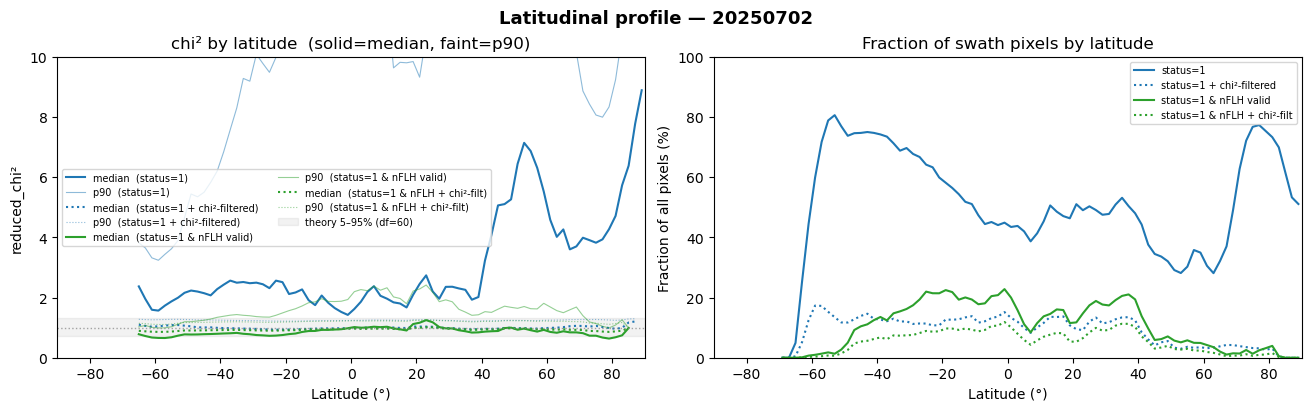

In [7]:
# ── PLOT: median chi2 and convergence rate by latitude band ───────────────────
# Reload lat alongside chi2/stat for the spatial view
lat_all = []
for svd_path in svd_files:
    with nc.Dataset(svd_path, "r") as ds:
        lat_all.append(np.array(ds["latitude"][:]).ravel())
lat = np.concatenate(lat_all)

LAT_BINS    = np.arange(-90, 91, 2)   # 2° bands
lat_centers = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# chi2 in-band filter reusing CHI2_LO/CHI2_HI from the stats cell (df=60)
chi2_inband = np.isfinite(chi2) & (chi2 >= CHI2_LO) & (chi2 <= CHI2_HI)

populations_lat = [
    ((stat == 1),                            "status=1",                    "C0", "-"),
    ((stat == 1) & chi2_inband,              "status=1 + chi²-filtered",    "C0", ":"),
    ((stat == 1) & nflh_ok,                  "status=1 & nFLH valid",       "C2", "-"),
    ((stat == 1) & nflh_ok & chi2_inband,    "status=1 & nFLH + chi²-filt", "C2", ":"),
]

# Pre-compute per-band stats for each population
results = []
for base_mask, label, color, ls in populations_lat:
    med    = np.full(len(lat_centers), np.nan)
    pct90  = np.full(len(lat_centers), np.nan)
    frac   = np.full(len(lat_centers), np.nan)   # fraction of ALL pixels in band
    for i, (lo, hi) in enumerate(zip(LAT_BINS[:-1], LAT_BINS[1:])):
        in_b = (lat >= lo) & (lat < hi)
        n_total = np.sum(in_b)
        if n_total == 0:
            continue
        frac[i] = np.sum(in_b & base_mask) / n_total * 100
        vals = chi2[in_b & base_mask & np.isfinite(chi2)]
        if len(vals) > 0:
            med[i]   = np.median(vals)
            pct90[i] = np.percentile(vals, 90)
    results.append((med, pct90, frac, label, color, ls))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
fig.suptitle(f"Latitudinal profile — {DATE}", fontsize=13, fontweight="bold")

# ── left: chi² by latitude ────────────────────────────────────────────────────
ax = axes[0]
for med, pct90, frac, label, color, ls in results:
    ax.plot(lat_centers, med,   color=color, linewidth=1.5, linestyle=ls,
            label=f"median  ({label})")
    ax.plot(lat_centers, pct90, color=color, linewidth=0.8, linestyle=ls,
            alpha=0.5, label=f"p90  ({label})")
ax.axhspan(CHI2_LO, CHI2_HI, color="gray", alpha=0.10,
           label=f"theory 5–95% (df={DF_THEORY})")
ax.axhline(1.0, color="gray", linestyle=":",  linewidth=1, alpha=0.7)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("reduced_chi²")
ax.set_xlim(-90, 90)
ax.set_ylim(0, 10)
ax.legend(fontsize=7, ncol=2)
ax.set_title("chi² by latitude  (solid=median, faint=p90)")

# ── right: fraction of all swath pixels by latitude ──────────────────────────
ax = axes[1]
for med, pct90, frac, label, color, ls in results:
    ax.plot(lat_centers, frac, color=color, linewidth=1.5, linestyle=ls, label=label)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Fraction of all pixels (%)")
ax.set_xlim(-90, 90)
ax.set_ylim(0, 100)
ax.legend(fontsize=7)
ax.set_title("Fraction of swath pixels by latitude")

plt.show()


Population sizes:
  (1) all                           : 299,208,348
  (2) status=0|1 + chi²-filter      : 32,875,206  (11.0%)
  (3) (2) + l2_flags + mean_rad≤30 : 25,839,142  (8.6%)


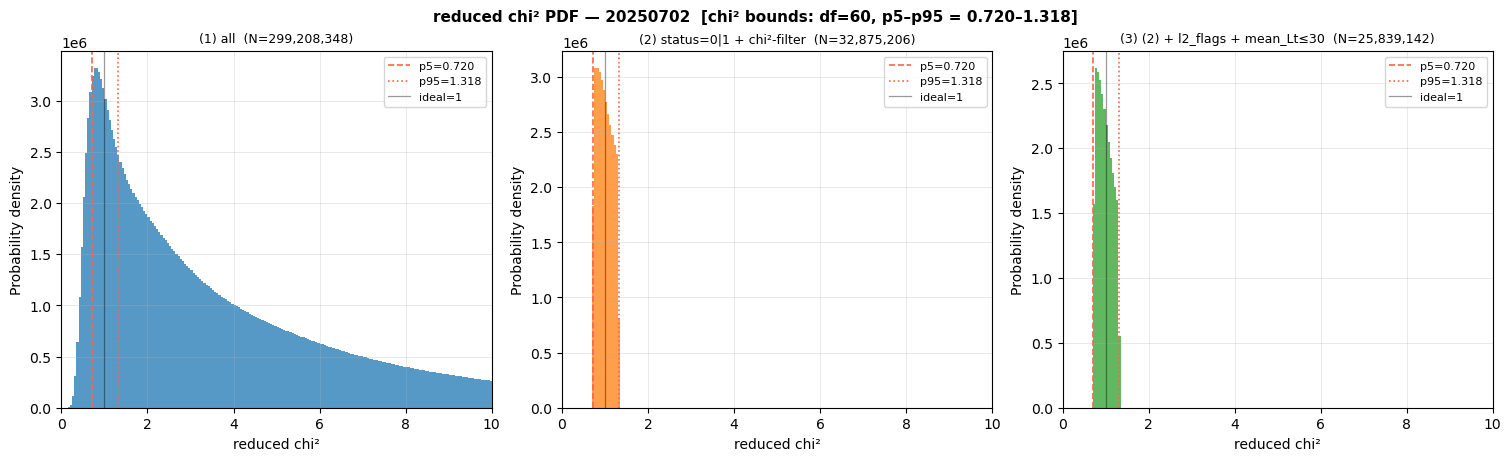

In [12]:
# ── PLOT: reduced_chi2 PDF — 3 populations ───────────────────────────────────
# (1) all retrievals
# (2) status=0|1  +  chi2 in [CHI2_LO, CHI2_HI]
# (3) (2)  +  l2_flags_reject=["LAND","COASTZ","HISOLZEN"]  +  mean_Lt ≤ 30 W m⁻² sr⁻¹ µm⁻¹
#
# CHI2_LO / CHI2_HI / DF_THEORY from the summary statistics cell (cell 5).
# Population 3 requires a second pass over SVD+L1B files to compute mean_rad.

# ── flag reject mask: LAND(bit1) | COASTZ(bit6) | HISOLZEN(bit12) ─────────────
L2FLAGS_REJECT = np.uint32(2 | 64 | 4096)     # 4162

# ── populations 1 & 2 (from already-loaded flat arrays) ──────────────────────
mask_chi2_stat = (
    ((stat == 0) | (stat == 1)) &
    np.isfinite(chi2) &
    (chi2 >= CHI2_LO) & (chi2 <= CHI2_HI)
)

# ── population 3: also apply l2_flags + mean_Lt filter (second pass) ─────────
L1B_DIR_LOC    = "/home/zhe2/data/PACE/L1B_V3"
LAMBDA_MIN_LOC = 640.0
LAMBDA_MAX_LOC = 756.0
MAX_MEAN_RAD   = 30.0      # W m⁻² sr⁻¹ µm⁻¹

L1B_RE_LOC = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L1B\.")
l1b_idx_loc = {
    L1B_RE_LOC.match(fn).group(1): os.path.join(L1B_DIR_LOC, fn)
    for fn in os.listdir(L1B_DIR_LOC) if L1B_RE_LOC.match(fn)
}
def _match_l1b(gid):
    if gid in l1b_idx_loc: return l1b_idx_loc[gid]
    for k, v in l1b_idx_loc.items():
        if k[:-2] == gid[:-2]: return v
    return None

# ── population 3 mask ─────────────────────────────────────────────────────────
mask_full = (
    mask_chi2_stat &
    ((flags.astype(np.uint32) & L2FLAGS_REJECT) == 0)
)

# ── collect chi2 values per population ───────────────────────────────────────
finite = np.isfinite(chi2)
pop1 = chi2[finite]
pop2 = chi2[mask_chi2_stat]
pop3 = chi2[mask_full]

print(f"\nPopulation sizes:")
print(f"  (1) all                           : {len(pop1):>10,}")
print(f"  (2) status=0|1 + chi²-filter      : {len(pop2):>10,}  ({100*len(pop2)/max(len(pop1),1):.1f}%)")
print(f"  (3) (2) + l2_flags + mean_rad≤{MAX_MEAN_RAD:.0f} : {len(pop3):>10,}  ({100*len(pop3)/max(len(pop1),1):.1f}%)")

# ── 3-panel PDF plot ──────────────────────────────────────────────────────────
bins = np.linspace(*CHI2_XLIM, CHI2_NBINS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
fig.suptitle(
    f"reduced chi² PDF — {DATE}  "
    f"[chi² bounds: df={DF_THEORY}, p5–p95 = {CHI2_LO:.3f}–{CHI2_HI:.3f}]",
    fontsize=11, fontweight="bold",
)

plot_data = [
    (pop1, "C0", f"(1) all  (N={len(pop1):,})"),
    (pop2, "C1", f"(2) status=0|1 + chi²-filter  (N={len(pop2):,})"),
    (pop3, "C2", f"(3) (2) + l2_flags + mean_Lt≤{MAX_MEAN_RAD:.0f}  (N={len(pop3):,})"),
]

for ax, (vals, color, label) in zip(axes, plot_data):
    ax.hist(vals, bins=bins, density=False, alpha=0.75, color=color)
    ax.axvline(CHI2_LO, color="tomato", lw=1.2, ls="--", label=f"p5={CHI2_LO:.3f}")
    ax.axvline(CHI2_HI, color="tomato", lw=1.2, ls=":",  label=f"p95={CHI2_HI:.3f}")
    ax.axvline(1.0,     color="k",      lw=0.9, ls="-",  alpha=0.4, label="ideal=1")
    ax.set_xlabel("reduced chi²", fontsize=10)
    ax.set_ylabel("Probability density", fontsize=10)
    ax.set_title(label, fontsize=9)
    ax.set_xlim(*CHI2_XLIM)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()


#### <b>SNR modelling</b>

In [ ]:
# ── L1B RADIANCE SPECTRA + SNR FOR RANDOM PIXELS ─────────────────────────────
import random
L1B_DIR  = "/home/zhe2/data/PACE/L1B_V3"
L1B_RE   = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L1B\.V3\.nc$")
LAMBDA_MIN, LAMBDA_MAX = 640.0, 756.0   # retrieval window [nm]

# ── build L1B index for the selected date ─────────────────────────────────────
l1b_idx = {}
for fn in os.listdir(L1B_DIR):
    m = L1B_RE.match(fn)
    if m and fn.startswith(f"PACE_OCI.{DATE}"):
        l1b_idx[m.group(1)] = os.path.join(L1B_DIR, fn)

print(f"Found {len(l1b_idx)} L1B files for {DATE}")

# ── collect (svd_path, scan_idx_0based, pix_idx_0based, rmse) for status=1 ────
# We already have stat, chi2 arrays from cell 1; rebuild a flat pixel→file map.
pixel_records = []   # (svd_path, l1b_path, scan0, pix0, rmse_val)

for svd_path in svd_files:
    m   = SVD_RE.match(os.path.basename(svd_path))
    gid = m.group(1)
    l1b_path = l1b_idx.get(gid)
    if l1b_path is None:
        continue

    with nc.Dataset(svd_path, "r") as ds:
        stat_g  = np.array(ds["status_code"][:])       # (scans, pixels)
        rmse_g  = np.array(ds["rmse"][:])
        si      = np.array(ds["source_scan_index"][:])  # 1-based, len=scans
        pi      = np.array(ds["source_pixel_index"][:]) # 1-based, len=pixels

    rows, cols = np.where(stat_g == 1)
    for r, c in zip(rows, cols):
        pixel_records.append((svd_path, l1b_path,
                               int(si[r]) - 1,   # → 0-based L1B scan
                               int(pi[c]) - 1,   # → 0-based L1B pixel
                               float(rmse_g[r, c])))

print(f"status=1 pixels available: {len(pixel_records):,}")


Found 147 L1B files for 20250702
status=1 pixels available: 169,371,968


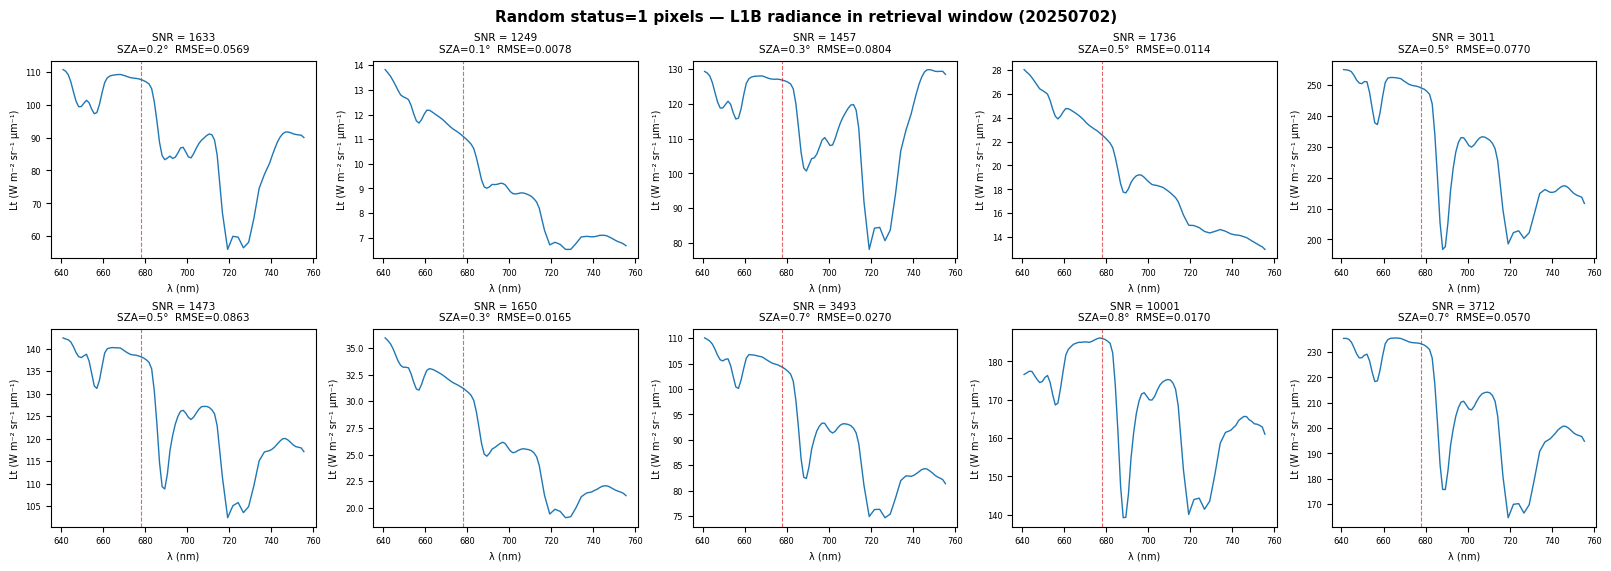

In [ ]:
# ── pick N random pixels ───────────────────────────────────────────────────────
random.seed(42)
N_EXAMPLES = 10
chosen = random.sample(pixel_records, min(N_EXAMPLES, len(pixel_records)))

# ── load L1B spectra one file at a time, then close immediately ───────────────
# Group chosen pixels by L1B file to minimise open/close calls.
from collections import defaultdict
by_l1b = defaultdict(list)
for rec in chosen:
    by_l1b[rec[1]].append(rec)   # key = l1b_path

spectra = {}   # (svd_path, scan0, pix0) → (wl, radiance, snr)

for l1b_path, recs in by_l1b.items():
    ds = nc.Dataset(l1b_path, "r")
    try:
        wl_all  = np.array(ds["sensor_band_parameters/red_wavelength"][:])
        F0_all  = np.array(ds["sensor_band_parameters/red_solar_irradiance"][:])
        win     = np.where((wl_all >= LAMBDA_MIN) & (wl_all <= LAMBDA_MAX))[0]
        wl      = wl_all[win]
        F0      = F0_all[win]
        esd     = float(ds.getncattr("earth_sun_distance_correction"))

        for (svd_path, _, scan0, pix0, rmse_val) in recs:
            rhot = np.array(ds["observation_data/rhot_red"][win, scan0, pix0],
                            dtype=np.float32)
            sza_raw = ds["geolocation_data/solar_zenith"][scan0, pix0]
            sza_deg = float(sza_raw)   # netCDF4 auto-applies scale_factor on read
            cos_sza = np.cos(np.deg2rad(sza_deg))

            # Lt = rhot * F0 * cos(SZA) / (pi * esd)  [W m⁻² sr⁻¹ µm⁻¹]
            # esd = earth_sun_distance_correction (global L1B attribute)
            Lt   = rhot * F0 * cos_sza / (np.pi * esd)
            mean_signal = float(np.mean(Lt))
            snr  = mean_signal / rmse_val if rmse_val > 0 else np.nan
            spectra[(svd_path, scan0, pix0)] = (wl, Lt, snr, sza_deg, mean_signal, rmse_val)
    finally:
        ds.close()   # always release memory

# ── plot ──────────────────────────────────────────────────────────────────────
ncols = 5
nrows = (N_EXAMPLES + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.8),
                          constrained_layout=True)
fig.suptitle(f"Random status=1 pixels — L1B radiance in retrieval window ({DATE})",
             fontsize=11, fontweight="bold")

for ax, rec in zip(axes.ravel(), chosen):
    key = (rec[0], rec[2], rec[3])
    if key not in spectra:
        ax.set_visible(False)
        continue
    wl, Lt, snr, sza, mean_sig, rmse_val = spectra[key]
    ax.plot(wl, Lt, linewidth=1, color="C0")
    ax.axvline(678, color="C3", linestyle="--", linewidth=0.8, alpha=0.7)  # SIF peak
    ax.set_title(f"SNR = {snr:.0f}\n"
                 f"SZA={sza:.1f}°  RMSE={rmse_val:.4f}", fontsize=7.5)
    ax.set_xlabel("λ (nm)", fontsize=7)
    ax.set_ylabel("Lt (W m⁻² sr⁻¹ µm⁻¹)", fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes.ravel()[len(chosen):]:
    ax.set_visible(False)

plt.show()

In [ ]:
# ── ONE GRANULE: MEAN RADIANCE MAP + 10 PIXEL SPECTRA ────────────────────────
import random

LAMBDA_MIN_VIS, LAMBDA_MAX_VIS = 640.0, 756.0   # retrieval window
N_PIX = 20

# Pick the first SVD granule of the date
first_svd = "/home/zhe2/data/PACE/svd_retrieval_output/interim_20250702T170504_svd_retrieval_full_gpu.nc"
m_g  = SVD_RE.match(os.path.basename(first_svd))
gid  = m_g.group(1)
l1b_path_g = l1b_idx.get(gid)
l2_path_g  = match_l2(gid)
print(f"Granule : {gid}")
print(f"L1B     : {l1b_path_g}")
print(f"L2 AOP  : {l2_path_g}")

# ── SVD variables ─────────────────────────────────────────────────────────────
with nc.Dataset(first_svd, "r") as ds:
    rmse_g = np.array(ds["rmse"][:], dtype=np.float32)          # (scans, pixels)
    sif_g  = np.array(ds["sif_radiance_678nm"][:], dtype=np.float32)
    lat_g  = np.array(ds["latitude"][:], dtype=np.float32)
    lon_g  = np.array(ds["longitude"][:], dtype=np.float32)

# ── L2 AOP nFLH ──────────────────────────────────────────────────────────────
if l2_path_g:
    with nc.Dataset(l2_path_g, "r") as ds:
        nv        = ds["geophysical_data/nflh"]
        nflh_fv_g = float(nv._FillValue) if hasattr(nv, "_FillValue") else None
        nflh_g    = np.ma.filled(nv[:], np.nan).astype(np.float32)
    if nflh_fv_g is not None:
        nflh_g[nflh_g == nflh_fv_g] = np.nan
else:
    nflh_g = np.full(lat_g.shape, np.nan, dtype=np.float32)

# ── L1B: load FULL radiance scene, then close ────────────────────────────────
print("Loading full L1B scene (~1.4 GB, may take 20–30 s) …", flush=True)
with nc.Dataset(l1b_path_g, "r") as ds:
    wl_full = np.array(ds["sensor_band_parameters/red_wavelength"][:])        # (163,)
    F0_full = np.array(ds["sensor_band_parameters/red_solar_irradiance"][:])  # (163,)
    esd     = float(ds.getncattr("earth_sun_distance_correction"))

    sza_raw = np.array(ds["geolocation_data/solar_zenith"][:]).astype(np.float32)
    # netCDF4 auto-applies scale_factor=0.01 on read → values already in degrees
    cos_sza = np.cos(np.deg2rad(sza_raw))                        # (scans, pixels)

    rhot_full = np.array(ds["observation_data/rhot_red"][:], dtype=np.float32)
    # file closed here → all memory now in rhot_full

# Lt_full: (163, scans, pixels)  [W m⁻² sr⁻¹ µm⁻¹]
Lt_full = rhot_full * F0_full[:, None, None] * cos_sza[None, :, :] / (np.pi * esd)
del rhot_full   # free ~1.4 GB

win         = np.where((wl_full >= LAMBDA_MIN_VIS) & (wl_full <= LAMBDA_MAX_VIS))[0]
mean_Lt_map = Lt_full[win].mean(axis=0)   # (scans, pixels)
print("Done.", flush=True)

# ── Sample N_PIX pixels for plotting ─────────────────────────────────────────
random.seed(42)
scans_n, pix_n = lat_g.shape
flat_idx = random.sample(range(scans_n * pix_n), N_PIX)
scan_ch  = [idx // pix_n for idx in flat_idx]
pix_ch   = [idx  % pix_n for idx in flat_idx]

# Spectra and per-pixel scalar metadata for chosen pixels
Lt_ch       = Lt_full[:, scan_ch, pix_ch]        # (163, N_PIX)
mean_Lt_ch  = Lt_ch[win].mean(axis=0).ravel()    # (N_PIX,)
sza_ch      = sza_raw[scan_ch, pix_ch].ravel()   # (N_PIX,)



Granule : 20250702T170504
L1B     : /home/zhe2/data/PACE/L1B_V3/PACE_OCI.20250702T170504.L1B.V3.nc
L2 AOP  : /home/zhe2/data/PACE/L2_AOP_V3.1/PACE_OCI.20250702T170504.L2.OC_AOP.V3_1.nc
Loading full L1B scene (~1.4 GB, may take 20–30 s) …


Done.


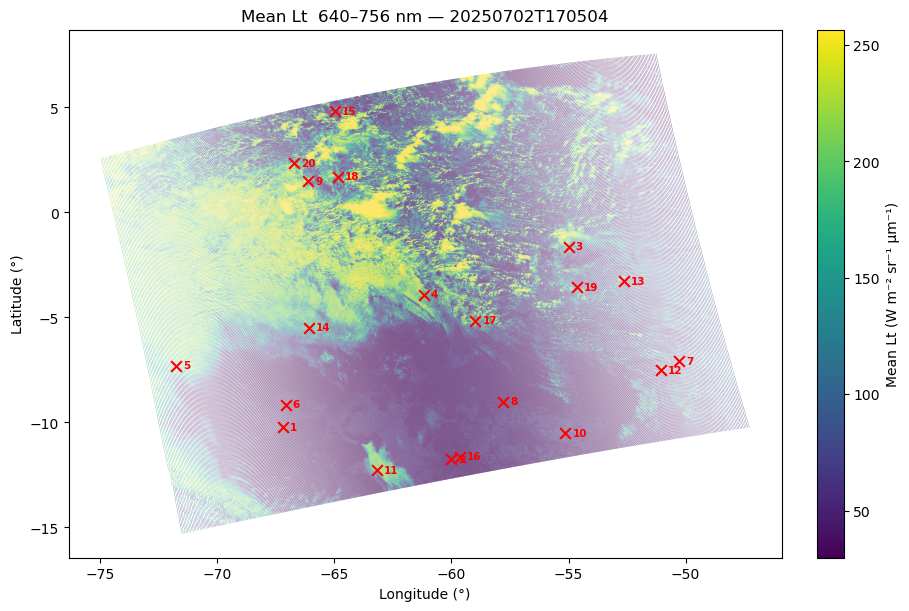

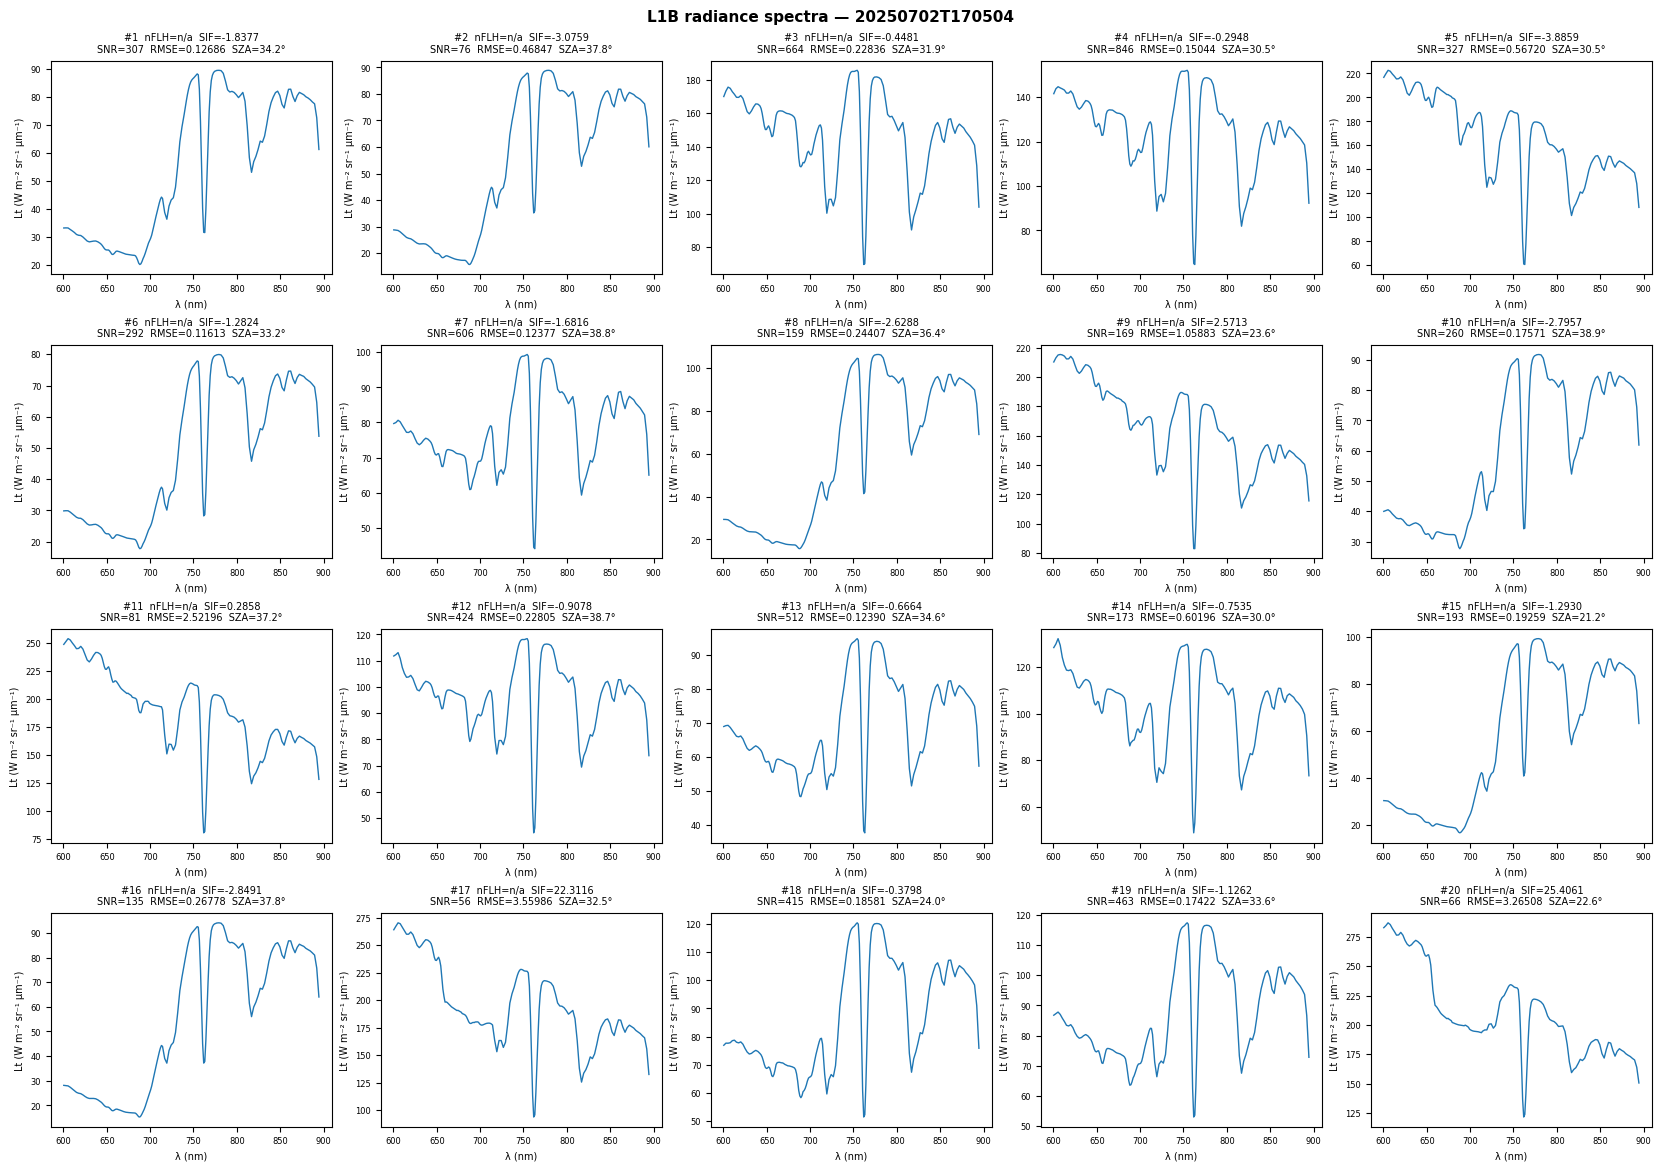

In [ ]:

# ── FIGURE 1: Mean radiance map + overlay ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
vlo, vhi = np.nanpercentile(mean_Lt_map, [2, 98])
sc = ax.scatter(lon_g.ravel(), lat_g.ravel(),
                c=mean_Lt_map.ravel(), s=0.04,
                cmap="viridis", vmin=vlo, vmax=vhi, linewidths=0)
plt.colorbar(sc, ax=ax, label="Mean Lt (W m⁻² sr⁻¹ µm⁻¹)")
xs = [lon_g[s, p] for s, p in zip(scan_ch, pix_ch)]
ys = [lat_g[s, p] for s, p in zip(scan_ch, pix_ch)]
ax.scatter(xs, ys, c="red", s=60, marker="x", linewidths=1.5, zorder=5)
for k, (x, y) in enumerate(zip(xs, ys)):
    ax.text(x + 0.3, y, str(k + 1), color="red", fontsize=7.5, va="center", fontweight="bold")
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
ax.set_title(f"Mean Lt  {LAMBDA_MIN_VIS:.0f}–{LAMBDA_MAX_VIS:.0f} nm — {gid}")
plt.show()

# ── FIGURE 2: Radiance spectra of chosen pixels ───────────────────────────────
ncols, nrows = 5, (N_PIX + 4) // 5
fig2, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.3, nrows * 2.9),
                           constrained_layout=True)
fig2.suptitle(f"L1B radiance spectra — {gid}", fontsize=11, fontweight="bold")

for k, (s, p) in enumerate(zip(scan_ch, pix_ch)):
    ax       = axes.ravel()[k]
    rmse_val = float(rmse_g[s, p])
    sif_val  = float(sif_g[s, p])
    nflh_val = float(nflh_g[s, p])
    sza_val  = float(sza_ch[k])
    sig_val  = float(mean_Lt_ch[k])
    snr_val  = sig_val / rmse_val if (np.isfinite(rmse_val) and rmse_val > 0) else np.nan

    ax.plot(wl_full, Lt_ch[:, k], linewidth=1.0, color="C0")
    nflh_str = f"{nflh_val:.3f}" if np.isfinite(nflh_val) else "n/a"
    ax.set_title(
        f"#{k+1}  nFLH={nflh_str}  SIF={sif_val:.4f}\n"
        f"SNR={snr_val:.0f}  RMSE={rmse_val:.5f}  SZA={sza_val:.1f}°",
        fontsize=7
    )
    ax.set_xlabel("λ (nm)", fontsize=7)
    ax.set_ylabel("Lt (W m⁻² sr⁻¹ µm⁻¹)", fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes.ravel()[N_PIX:]:
    ax.set_visible(False)
plt.show()

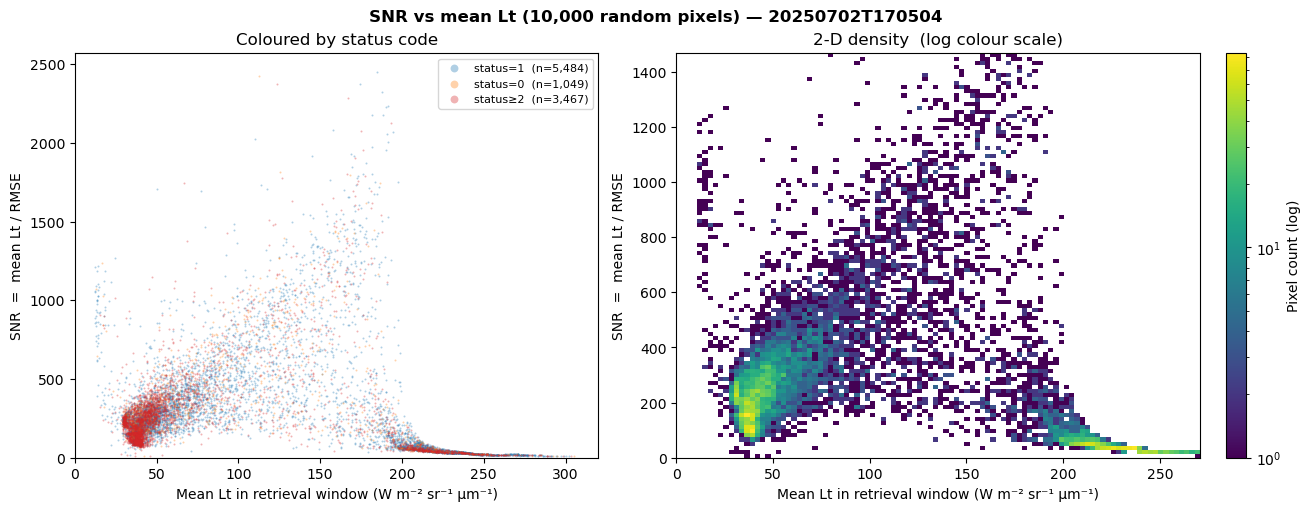

status=1 in sample: 5,484
  SNR  median=234.6  p10=35.0  p90=751.3


In [ ]:
# ── SNR vs mean Lt — 10k random pixels ───────────────────────────────────────
# Reuses Lt_full, mean_Lt_map, rmse_g, lat_g from the loading cell above.
N_SCATTER = 10_000

random.seed(7)
scans_n, pix_n = lat_g.shape
samp_idx = random.sample(range(scans_n * pix_n), N_SCATTER)
s_idx    = np.array([i // pix_n for i in samp_idx])
p_idx    = np.array([i  % pix_n for i in samp_idx])

mean_Lt_s = mean_Lt_map[s_idx, p_idx]
rmse_s    = rmse_g[s_idx, p_idx]

# load stat_g if not yet in scope
try:
    stat_s = stat_g[s_idx, p_idx]
except NameError:
    with nc.Dataset(first_svd, "r") as ds:
        stat_g = np.array(ds["status_code"][:])
    stat_s = stat_g[s_idx, p_idx]

with np.errstate(divide="ignore", invalid="ignore"):
    snr_s = np.where(rmse_s > 0, mean_Lt_s / rmse_s, np.nan)

# ── scatter + 2-D density ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle(f"SNR vs mean Lt ({N_SCATTER:,} random pixels) — {gid}",
             fontsize=12, fontweight="bold")

STATUS_GROUPS = [
    (stat_s == 1,        "C0", "status=1"),
    (stat_s == 0,        "C1", "status=0"),
    (stat_s >= 2,        "C3", "status≥2"),
]

# left: scatter coloured by status
ax = axes[0]
for mask, color, label in STATUS_GROUPS:
    ok = mask & np.isfinite(snr_s) & np.isfinite(mean_Lt_s)
    ax.scatter(mean_Lt_s[ok], snr_s[ok],
               s=2, alpha=0.35, color=color, linewidths=0,
               label=f"{label}  (n={ok.sum():,})")
ax.set_xlabel("Mean Lt in retrieval window (W m⁻² sr⁻¹ µm⁻¹)")
ax.set_ylabel("SNR  =  mean Lt / RMSE")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, markerscale=4)
ax.set_title("Coloured by status code")

# right: 2-D histogram for density (all finite pixels)
ax = axes[1]
ok = np.isfinite(snr_s) & np.isfinite(mean_Lt_s) & (mean_Lt_s > 0) & (snr_s > 0)
xmax = np.nanpercentile(mean_Lt_s[ok], 99)
ymax = np.nanpercentile(snr_s[ok],     99)
_, _, _, img = ax.hist2d(
    mean_Lt_s[ok], snr_s[ok],
    bins=100, range=[[0, xmax], [0, ymax]],
    cmap="viridis", norm=plt.matplotlib.colors.LogNorm()
)
plt.colorbar(img, ax=ax, label="Pixel count (log)")
ax.set_xlabel("Mean Lt in retrieval window (W m⁻² sr⁻¹ µm⁻¹)")
ax.set_ylabel("SNR  =  mean Lt / RMSE")
ax.set_title("2-D density  (log colour scale)")

plt.show()

# quick stats for status=1
s1 = (stat_s == 1) & np.isfinite(snr_s)
print(f"status=1 in sample: {s1.sum():,}")
print(f"  SNR  median={np.nanmedian(snr_s[s1]):.1f}  "
      f"p10={np.nanpercentile(snr_s[s1],10):.1f}  "
      f"p90={np.nanpercentile(snr_s[s1],90):.1f}")

#### <b>nFLH distribution binned by Chlorophyll concentration</b>

Background pixels (nFLH>0, chl>0): 35,532,860 / 314,639,376
SVD filter-3 pixels (nFLH>0, chl>0): 15,363,177


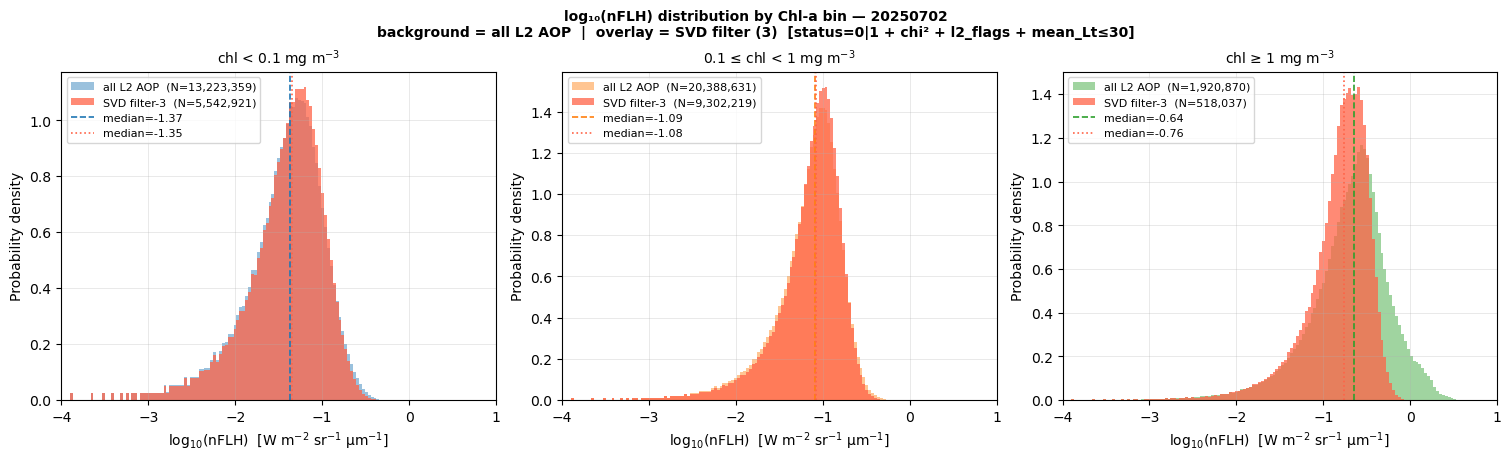

In [17]:
# ── log(nFLH) distributions binned by Chlorophyll-a ─────────────────────────
# Background : all L2 AOP + L2 BGC V3.1 granules matching DATE.
# Overlay    : SVD retrieval pixels passing filter (3) from cell 7
#              (status=0|1 + chi²-filter + l2_flags + mean_Lt≤30).
# Requires cell 7 to have been executed (mask_full must be defined).

L2BGC_DIR = "/home/zhe2/data/PACE/L2_BGC_V3.1"
L2BGC_RE  = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L2\.OC_BGC.*\.nc$")

bgc_idx = {
    L2BGC_RE.match(fn).group(1): os.path.join(L2BGC_DIR, fn)
    for fn in os.listdir(L2BGC_DIR) if L2BGC_RE.match(fn)
}

def match_bgc(gid):
    if gid in bgc_idx: return bgc_idx[gid]
    for k, v in bgc_idx.items():
        if k[:-2] == gid[:-2]: return v
    return None

# ── collect all valid (nFLH, chlor_a) pairs ──────────────────────────────────
nflh_all = []
chl_all  = []

for gid, l2_path in sorted(l2aop_idx.items()):
    if not gid.startswith(DATE):
        continue
    bgc_path = match_bgc(gid)
    if bgc_path is None:
        print(f"  {gid}: no BGC file — skipped")
        continue

    with nc.Dataset(l2_path, "r") as ds_l2:
        nflh_raw = np.ma.filled(
            ds_l2["geophysical_data/nflh"][:], np.nan
        ).ravel().astype(np.float32)

    with nc.Dataset(bgc_path, "r") as ds_bgc:
        chl_raw = np.ma.filled(
            ds_bgc["geophysical_data/chlor_a"][:], np.nan
        ).ravel().astype(np.float32)

    nflh_all.append(nflh_raw)
    chl_all.append(chl_raw)

nflh_flat = np.concatenate(nflh_all)
chl_flat  = np.concatenate(chl_all)

# ── background: both products finite and nFLH > 0 ────────────────────────────
valid_bg = (
    np.isfinite(nflh_flat) & (nflh_flat > 0) &
    np.isfinite(chl_flat)  & (chl_flat  > 0)
)
log_nflh_bg = np.log10(nflh_flat[valid_bg])
chl_bg      = chl_flat[valid_bg]
print(f"Background pixels (nFLH>0, chl>0): {valid_bg.sum():,} / {len(valid_bg):,}")

# ── overlay: SVD pixels passing filter (3) — extract nFLH+chl via source indices
# Loops svd_files in the SAME ORDER as cell 7 so indices align with mask_full.
nflh_svd_all = []
chl_svd_all  = []

for svd_path in svd_files:
    m_re  = SVD_RE.match(os.path.basename(svd_path))
    gid   = m_re.group(1)
    l2_path  = match_l2(gid)
    bgc_path = match_bgc(gid)

    with nc.Dataset(svd_path, "r") as ds:
        n_scan   = ds.dimensions["scans"].size
        n_pix    = ds.dimensions["pixels"].size
        src_scan = np.array(ds["source_scan_index"][:]) - 1   # 0-based
        src_pix  = np.array(ds["source_pixel_index"][:]) - 1

    n_total = n_scan * n_pix

    if l2_path:
        with nc.Dataset(l2_path, "r") as ds_l2:
            nflh_g = np.ma.filled(
                ds_l2["geophysical_data/nflh"][src_scan, :][:, src_pix], np.nan
            ).ravel().astype(np.float32)
    else:
        nflh_g = np.full(n_total, np.nan, dtype=np.float32)

    if bgc_path:
        with nc.Dataset(bgc_path, "r") as ds_bgc:
            chl_g = np.ma.filled(
                ds_bgc["geophysical_data/chlor_a"][src_scan, :][:, src_pix], np.nan
            ).ravel().astype(np.float32)
    else:
        chl_g = np.full(n_total, np.nan, dtype=np.float32)

    nflh_svd_all.append(nflh_g)
    chl_svd_all.append(chl_g)

nflh_svd_flat = np.concatenate(nflh_svd_all)
chl_svd_flat  = np.concatenate(chl_svd_all)

# apply filter (3) mask from cell 7 + require nFLH > 0 and chl > 0
valid_svd = (
    mask_full &
    np.isfinite(nflh_svd_flat) & (nflh_svd_flat > 0) &
    np.isfinite(chl_svd_flat)  & (chl_svd_flat  > 0)
)
log_nflh_svd = np.log10(nflh_svd_flat[valid_svd])
chl_svd      = chl_svd_flat[valid_svd]
print(f"SVD filter-3 pixels (nFLH>0, chl>0): {valid_svd.sum():,}")

# ── 3 Chl bins ────────────────────────────────────────────────────────────────
bins_def = [
    (chl_bg < 0.1,                    chl_svd < 0.1,
     r"chl < 0.1 mg m$^{-3}$",        "C0"),
    ((chl_bg >= 0.1) & (chl_bg < 1),  (chl_svd >= 0.1) & (chl_svd < 1),
     r"0.1 ≤ chl < 1 mg m$^{-3}$",    "C1"),
    (chl_bg >= 1.0,                   chl_svd >= 1.0,
     r"chl ≥ 1 mg m$^{-3}$",          "C2"),
]

log_bins = np.linspace(-4, 1, 150)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
fig.suptitle(
    f"log₁₀(nFLH) distribution by Chl-a bin — {DATE}\n"
    r"background = all L2 AOP  |  overlay = SVD filter (3)  "
    r"[status=0|1 + chi² + l2_flags + mean_Lt≤30]",
    fontsize=10, fontweight="bold",
)

for ax, (m_bg, m_svd, label, color) in zip(axes, bins_def):
    bg_vals  = log_nflh_bg[m_bg]
    svd_vals = log_nflh_svd[m_svd]

    ax.hist(bg_vals,  bins=log_bins, density=True, alpha=0.45,
            color=color, label=f"all L2 AOP  (N={len(bg_vals):,})")
    if len(svd_vals):
        ax.hist(svd_vals, bins=log_bins, density=True, alpha=0.75,
                color="tomato", label=f"SVD filter-3  (N={len(svd_vals):,})")

    # dashed medians
    for vals, c, ls in [(bg_vals, color, "--"), (svd_vals, "tomato", ":")]:
        if len(vals):
            ax.axvline(np.median(vals), color=c, lw=1.2, ls=ls,
                       label=f"median={np.median(vals):.2f}")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel(r"log$_{10}$(nFLH)  [W m$^{-2}$ sr$^{-1}$ µm$^{-1}$]", fontsize=10)
    ax.set_ylabel("Probability density", fontsize=10)
    ax.set_xlim(log_bins[0], log_bins[-1])
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()